# Exercise 10.1a solution


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def transition_matrix(k_co, k_oc, k_oi, k_io):
    """Build the 3x3 transition rate matrix for the C-O-I model."""
    # State indices
    C = 0
    O = 1
    I = 2

    n = 3
    A = np.zeros((n, n))

    # Off-diagonal transition rates
    # A[to_state, from_state] = rate
    A[O, C] = k_co  # C -> O
    A[C, O] = k_oc  # O -> C
    A[I, O] = k_oi  # O -> I
    A[O, I] = k_io  # I -> O

    # Diagonal: each column sums to zero
    for i in range(n):
        A[i, i] = -np.sum(A[:, i]) + A[i, i]

    return A


# Set rate constants
k_co = 5
k_oc = 10
k_oi = 1
k_io = 0

A = transition_matrix(k_co, k_oc, k_oi, k_io)
print("Transition matrix A:")
print(A)

Transition matrix A:
[[ -5.  10.   0.]
 [  5. -11.   0.]
 [  0.   1.   0.]]


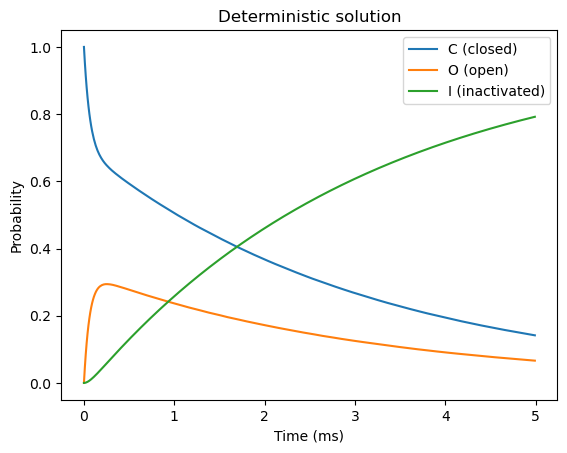

In [2]:
# Solve the deterministic ODE
def ode_system(t, y, A):
    return A @ y


y0 = np.array([1.0, 0.0, 0.0])  # Start in closed state
dt = 0.01
t_span = (0, 5)
t_eval = np.arange(*t_span, dt)

sol = solve_ivp(ode_system, t_span, y0, t_eval=t_eval, args=(A,))

plt.plot(sol.t, sol.y[0], label="C (closed)")
plt.plot(sol.t, sol.y[1], label="O (open)")
plt.plot(sol.t, sol.y[2], label="I (inactivated)")
plt.xlabel("Time (ms)")
plt.ylabel("Probability")
plt.title("Deterministic solution")
plt.legend()
plt.show()